# Fine Tuning using Optuna
We are using Optuna library which is a hyperparameter tuning library so rather than making each combination of parameter we give a range of each paramter and then the optuna helps in training the model using all possible and best hyperparameters. Stratified fold on the other hand helps us to break the dataset into K fold where the split of positive and negative example as in same ratio as original data.

In [5]:
%load_ext autoreload
%autoreload 2
import	sys;	sys.path.append("..")
from	src.data	import	get_splits
from	src.tracking	import	init,	log_run
X_tr,	X_te,	y_tr,	y_te	=	get_splits()
init()																																														#	experiment:	fraud-p1
spw	=	(y_tr	==	0).sum()	/	(y_tr	==	1).sum()

In [3]:
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

# n_estimators belongs here, never in the search space
FIXED = {"n_estimators": 200, "eval_metric": "aucpr",
         "tree_method": "hist", "n_jobs": 2, "random_state": 42}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
Xv, yv = X_tr.values, y_tr.values


def objective(trial):
    search = {
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 2 * spw, log=True),
    }
    scores = []
    for fold, (i_fit, i_val) in enumerate(cv.split(Xv, yv)):
        model = XGBClassifier(**{**search, **FIXED})
        model.fit(Xv[i_fit], yv[i_fit])
        p = model.predict_proba(Xv[i_val])[:, 1]
        scores.append(average_precision_score(yv[i_val], p))

        trial.report(float(np.mean(scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


study = optuna.create_study(
    direction="maximize",
    study_name="xgb_praauc",
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)
study.optimize(objective, n_trials=150, n_jobs=1)

print(f"best PR-AUC: {study.best_value:.4f}")
print(study.best_params)

[I 2026-09-04 01:12:24,280] A new study created in RDB with name: xgb_praauc
[I 2026-09-04 01:12:35,512] Trial 0 finished with value: 0.8473136522638134 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'subsample': 0.892797576724562, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 2, 'gamma': 0.7799726016810132, 'reg_lambda': 0.0017073967431528124, 'reg_alpha': 2.9154431891537547, 'scale_pos_weight': 69.32144559820078}. Best is trial 0 with value: 0.8473136522638134.
[I 2026-09-04 01:12:47,685] Trial 1 finished with value: 0.8008182460888965 and parameters: {'max_depth': 7, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 2, 'gamma': 0.9091248360355031, 'reg_lambda': 0.00541524411940254, 'reg_alpha': 0.016480446427978974, 'scale_pos_weight': 40.45995950617312}. Best is trial 0 with value: 0.8473136522638134.
[I 2026-09-04 01:12:57,094] Trial 2 finished with value: 0.83745

best PR-AUC: 0.8521
{'max_depth': 5, 'learning_rate': 0.06878090324608771, 'subsample': 0.8566762257054904, 'colsample_bytree': 0.9077283436024173, 'min_child_weight': 4, 'gamma': 1.798073818555928, 'reg_lambda': 0.0019965355610900024, 'reg_alpha': 0.09958053095757974, 'scale_pos_weight': 2.6736952436743975}


## Interview Important Stuff

In [2]:
import optuna
import optuna.visualization.matplotlib as ovm

ST = "sqlite:///optuna.db"

# check the exact name first — you renamed, or meant to
for s in optuna.get_all_study_summaries(ST):
    print(f"{s.study_name!r}  n_trials={s.n_trials}")

'xgb_praauc'  n_trials=150


In [3]:
study = optuna.load_study(study_name="xgb_praauc", storage=ST)
print(len(study.trials), "trials | best:", study.best_value)
print(study.best_params)

150 trials | best: 0.8521174851840646
{'max_depth': 5, 'learning_rate': 0.06878090324608771, 'subsample': 0.8566762257054904, 'colsample_bytree': 0.9077283436024173, 'min_child_weight': 4, 'gamma': 1.798073818555928, 'reg_lambda': 0.0019965355610900024, 'reg_alpha': 0.09958053095757974, 'scale_pos_weight': 2.6736952436743975}


C:\Users\Legion\AppData\Local\Temp\ipykernel_10500\3640333318.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)
C:\Users\Legion\AppData\Local\Temp\ipykernel_10500\3640333318.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

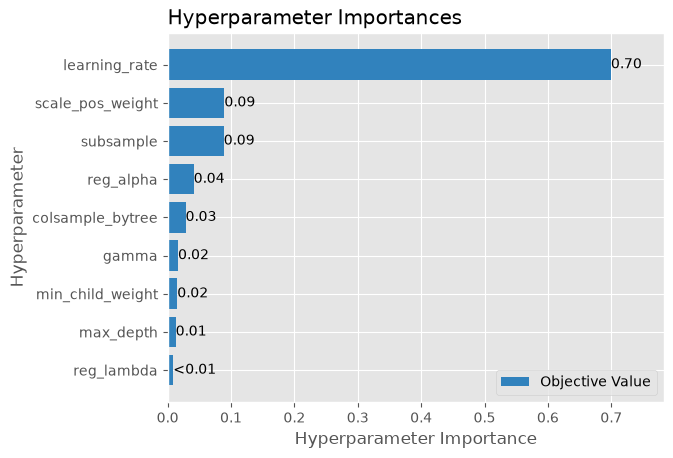

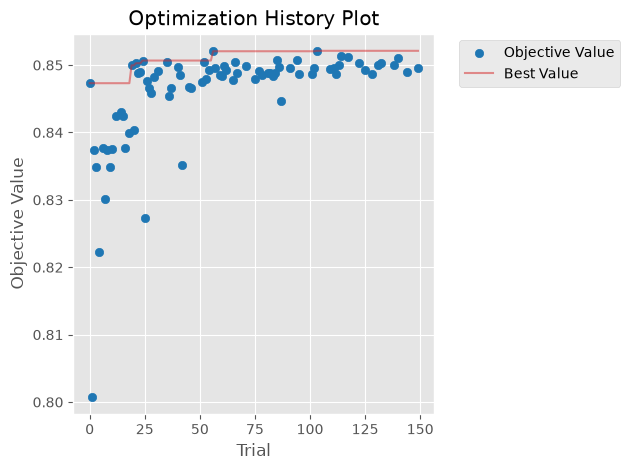

In [5]:
ovm.plot_param_importances(study)
ovm.plot_optimization_history(study)

### Teachback
Top 2 parameters are scale_pos_weight and learning as they drive the most variance in the performance score of model.
-- Why is min_child_weight capped low here when	standard practice is 20–50?
min child weight basically describes how many examples it should atleast be able to filter before prunning one node and as this data is highly imbalaance we would want to detect it even slightest trend in the fraud but keeping it too low will basically learn each example and that would just lead to overfitting.

In [6]:
# running the model at n_estimators = 400 with same hyperparameter
from pathlib import Path
import warnings, numpy as np, optuna
warnings.filterwarnings("ignore"); optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def project_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src").is_dir(): return p
    raise RuntimeError(f"no src/ found at or above {Path.cwd()}")

ROOT             = project_root()
STORAGE          = "sqlite:///" + (ROOT / "optuna.db").as_posix()
STUDY_NAME       = "xgb_praauc"          # or "xgb_praauc_fixed" if you renamed rather than reset
SEED             = 42
N_SPLITS_SEARCH  = 3
FINAL_ESTIMATORS = 400

study    = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE)
XGB_BEST = dict(study.best_params)
assert "n_estimators" not in XGB_BEST, "n_estimators leaked into the search space"

print(f"{len(study.trials)} trials | search PR-AUC {study.best_value:.4f} @200 trees")
print(f"scale_pos_weight tuned to {XGB_BEST['scale_pos_weight']:.1f} (class ratio {spw:.1f})")

cv     = StratifiedKFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
Xv, yv = X_tr.values, y_tr.values

150 trials | search PR-AUC 0.8521 @200 trees
scale_pos_weight tuned to 2.7 (class ratio 577.3)


In [8]:
## Tuning LightGBM on same fold
LGB_FIXED = {"objective": "binary", "n_estimators": 200, "n_jobs": 2,
             "verbosity": -1, "random_state": SEED}

def lgb_objective(trial):
    search = {
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127, log=True),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 2 * spw, log=True),
    }
    clash = set(search) & set(LGB_FIXED)
    if clash:
        raise ValueError(f"remove {clash} from the search space — they are fixed")

    scores = []
    for fold, (i_fit, i_val) in enumerate(cv.split(Xv, yv)):
        m = LGBMClassifier(**{**search, **LGB_FIXED})
        m.fit(Xv[i_fit], yv[i_fit])
        scores.append(average_precision_score(yv[i_val], m.predict_proba(Xv[i_val])[:, 1]))
        trial.report(float(np.mean(scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))

lgb_study = optuna.create_study(
    direction="maximize", study_name="lgbm_praauc", storage=STORAGE, load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
lgb_study.optimize(lgb_objective, n_trials=40, n_jobs=1)

LGB_BEST = dict(lgb_study.best_params)
print(f"{len(lgb_study.trials)} trials | search PR-AUC {lgb_study.best_value:.4f} @200 trees")
print(LGB_BEST)

40 trials | search PR-AUC 0.8448 @200 trees
{'num_leaves': 22, 'learning_rate': 0.047616352809760905, 'min_child_samples': 5, 'subsample': 0.9758873390019948, 'colsample_bytree': 0.5441758671529753, 'reg_lambda': 3.741904421879365, 'reg_alpha': 0.00942015866890884, 'scale_pos_weight': 2.721226688303677}


In [11]:
# Refitting both model for n_estimator 400
def cv_folds(make_model):
    out = []
    for i_fit, i_val in cv.split(Xv, yv):
        m = make_model(); m.fit(Xv[i_fit], yv[i_fit])
        out.append(average_precision_score(yv[i_val], m.predict_proba(Xv[i_val])[:, 1]))
    return np.array(out)

def xgb_final():
    return XGBClassifier(**{**XGB_BEST, "n_estimators": FINAL_ESTIMATORS,
                            "eval_metric": "aucpr", "tree_method": "hist",
                            "n_jobs": 2, "random_state": SEED})

def lgb_final():
    return LGBMClassifier(**{**LGB_BEST, "subsample_freq": 1, "objective": "binary",
                             "n_estimators": FINAL_ESTIMATORS, "n_jobs": 2,
                             "verbosity": -1, "random_state": SEED})

results = {"xgb_400": cv_folds(xgb_final), "lgbm_400": cv_folds(lgb_final)}
for k, v in results.items():
    print(f"{k:9s} {v.mean():.4f} ± {v.std(ddof=1):.4f}   folds={np.round(v, 4)}")

margin = results["xgb_400"].mean() - results["lgbm_400"].mean()
noise  = max(results["xgb_400"].std(ddof=1), results["lgbm_400"].std(ddof=1))
winner = "xgb_400" if margin > 0 else "lgbm_400"
print(f"\nmargin {margin:+.4f} | fold-to-fold noise {noise:.4f} → "
      f"{'REAL' if abs(margin) > noise else 'INSIDE THE NOISE'}")
print("champion:", winner)

xgb_400   0.8523 ± 0.0096   folds=[0.8458 0.8478 0.8633]
lgbm_400  0.8487 ± 0.0087   folds=[0.8438 0.8436 0.8587]

margin +0.0036 | fold-to-fold noise 0.0096 → INSIDE THE NOISE
champion: xgb_400


In [12]:
# logging the champion model
final_model = (xgb_final() if winner == "xgb_400" else lgb_final()).fit(X_tr, y_tr)

p_champ = log_run(f"champion_{winner}", final_model, X_tr, y_tr, X_te, y_te,
                  {**(XGB_BEST if winner == "xgb_400" else LGB_BEST),
                   "n_estimators": FINAL_ESTIMATORS,
                   "cv_pr_auc_mean": round(float(results[winner].mean()), 4),
                   "cv_pr_auc_std":  round(float(results[winner].std(ddof=1)), 4),
                   "margin":         round(float(margin), 4)})

## Champion: tuned XGBoost, n_estimators=400

Chosen on 3-fold CV inside X_tr (the same folds Block 1 searched on). The test
set was scored once, after the decision, and did not inform it.

| Model | CV PR-AUC @400 | Search trials @200 |
|---|---|---|
| XGBoost (Optuna) | 0.8523 ± 0.0096 | 150 |
| LightGBM (Optuna) | 0.8487 ± 0.0087 | 40 |

*Margin vs noise.* Margin +0.0036 against fold-to-fold std 0.0096 →INSIDE THE NOISE.

*Why 400 trees.* The search ran at 200 to fit the 8 GB budget; the refit doubles
the trees at the tuned learning_rate of 0.__.

*Caveat.* LightGBM got 40 trials to XGBoost's 150. A longer LGBM study could close
a margin this size.

In [17]:
## register the final run
import	mlflow,	mlflow.xgboost

with mlflow.start_run(run_name="champion_refit"):
    info = mlflow.xgboost.log_model(final_model, name="model")

mv = mlflow.register_model(info.model_uri, "fraud-champion")
mlflow.MlflowClient().set_registered_model_alias(
"fraud-champion",	"champion",	version=mv.version
)

Successfully registered model 'fraud-champion'.
Created version '1' of model 'fraud-champion'.


In [18]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
runs = mlflow.search_runs(experiment_names=["fraud-p1"], order_by=["metrics.pr_auc DESC"])
print(runs[["tags.mlflow.runName", "metrics.pr_auc", "metrics.roc_auc"]].to_string(index=False))

      tags.mlflow.runName  metrics.pr_auc  metrics.roc_auc
     xgb_scale_pos_weight        0.875108         0.985979
                xgb_smote        0.874428         0.980715
         champion_xgb_400        0.871936         0.978161
            random_forest        0.866944         0.961302
                xgb_scale        0.848627         0.970623
                 LightBGM        0.845325         0.939536
          xgb_undersample        0.779551         0.981845
          baseline_logreg        0.728925         0.972088
LightBGM_scale_pos_weight        0.090999         0.907203
           champion_refit             NaN              NaN


In [22]:
# ============================================================
# Verify the LightGBM + scale_pos_weight collapse
#   A) metrics logged in MLflow on Day 23
#   B) the logged model artifact, re-scored now
#   C) a fresh refit of the same config
# Requires PREAMBLE B (X_tr, y_tr, X_te, y_te, spw).
# ============================================================
import warnings, numpy as np, mlflow, mlflow.sklearn
warnings.filterwarnings("ignore")
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

RUN_NAME = "LightBGM_scale_pos_weight"        # the typo'd name, as logged
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# --- guard: same split, or the comparison means nothing ------------------
print(f"X_te {X_te.shape} | frauds in y_te {int(y_te.sum())} | spw {spw:.1f}")
assert int(y_te.sum()) == 98, "different split — re-check the Parquet cache"

# --- A) what MLflow recorded --------------------------------------------
runs = mlflow.search_runs(experiment_names=["fraud-p1"],
                          filter_string=f"tags.mlflow.runName = '{RUN_NAME}'")
assert len(runs) == 1, f"found {len(runs)} runs named {RUN_NAME}"
row = runs.iloc[0]
logged_pr, logged_roc = row["metrics.pr_auc"], row["metrics.roc_auc"]
print(f"\nA) logged Day 23   PR-AUC {logged_pr:.4f} | ROC-AUC {logged_roc:.4f}")
print("   params logged:", {k.split('.', 1)[1]: v for k, v in row.items()
                            if k.startswith("params.") and v is not None})

# --- B) the logged artifact, re-scored ----------------------------------
try:
    m_logged = mlflow.sklearn.load_model(f"runs:/{row['run_id']}/model")
    p_logged = m_logged.predict_proba(X_te)[:, 1]
    print(f"B) logged model    PR-AUC {average_precision_score(y_te, p_logged):.4f} "
          f"| ROC-AUC {roc_auc_score(y_te, p_logged):.4f}"
          f"  [unique probs {len(np.unique(p_logged))}]")
    print("   its params:", {k: v for k, v in m_logged.get_params().items()
                             if k in ("n_estimators", "num_leaves", "learning_rate",
                                      "scale_pos_weight", "reg_lambda",
                                      "min_child_samples")})
except Exception as e:
    p_logged = None
    print(f"B) could not load artifact: {type(e).__name__}: {str(e)[:140]}")

# --- C) fresh refit of the Day 23 config --------------------------------
fresh = LGBMClassifier(objective="binary", n_estimators=200, num_leaves=31,
                       learning_rate=0.05, scale_pos_weight=spw,
                       n_jobs=2, verbosity=-1, random_state=42).fit(X_tr, y_tr)
p_fresh = fresh.predict_proba(X_te)[:, 1]
raw     = fresh.predict(X_te, raw_score=True)
pr_f, roc_f = average_precision_score(y_te, p_fresh), roc_auc_score(y_te, p_fresh)
print(f"C) fresh refit     PR-AUC {pr_f:.4f} | ROC-AUC {roc_f:.4f}"
      f"  [unique probs {len(np.unique(p_fresh))}]")
print(f"   raw score range {raw.min():.1f} .. {raw.max():.1f} "
      f"| PR-AUC on raw {average_precision_score(y_te, raw):.4f}")
print(f"   flagged at 0.5: {int((p_fresh > 0.5).sum())} of {len(p_fresh)}")

# --- verdict ------------------------------------------------------------
print(f"\nΔ(C − A) PR-AUC {pr_f - logged_pr:+.4f} | ROC-AUC {roc_f - logged_roc:+.4f}")
if p_logged is not None:
    same = np.allclose(p_logged, p_fresh)
    print("logged artifact and fresh refit give identical predictions:", same)

X_te (56962, 30) | frauds in y_te 98 | spw 577.3

A) logged Day 23   PR-AUC 0.0910 | ROC-AUC 0.9072
   params logged: {}


B) could not load artifact: MlflowException: Model does not have the "sklearn" flavor
C) fresh refit     PR-AUC 0.0733 | ROC-AUC 0.9160  [unique probs 9515]
   raw score range -594903.0 .. 4894472.9 | PR-AUC on raw 0.5746
   flagged at 0.5: 1010 of 56962

Δ(C − A) PR-AUC -0.0177 | ROC-AUC +0.0088


## Why LightGBM scored 0.09 with scale_pos_weight

| Run | PR-AUC | ROC-AUC |
|---|---|---|
| LightGBM (plain) | 0.845 | 0.940 |
| LightGBM + scale_pos_weight=577 | *0.091* | 0.907 |
| XGBoost + scale_pos_weight=577 | 0.875 | 0.986 |

The same change — weighting frauds 577× to match the class ratio — costs XGBoost
nothing and appears to destroy LightGBM. I first assumed the weighted model was
flagging fraud everywhere. It wasn't: it flagged 1,010 of 56,962 rows, which is 1.8%.
So that explanation was wrong, and the real one turned out to be two separate problems
stacked on top of each other.

### Problem 1: the score of 0.09 is a measurement artifact

A model doesn't output "fraud" or "not fraud" internally. It outputs a raw score —
any number, positive or negative — and then squashes it into a 0-to-1 probability.
PR-AUC doesn't care about the probability values themselves, only about the *ordering*:
are the real frauds near the top of the list?

The weighted model's raw scores ran from −594,903 to +4,894,473. Those are absurd
numbers — a healthy model's raw scores sit in single or double digits. And when a raw
score gets that large, the squashing step runs out of room: every score above roughly
+37 becomes the number 1.0 exactly. Not 0.998 or 0.9999. Identical 1.0.

So about 1,010 rows all ended up with the same probability, and the ranking inside
that group was destroyed. There were 98 real frauds in there among 912 false alarms,
and 98/1,010 ≈ 0.097 — which is, near enough, the 0.09 score. **PR-AUC couldn't sort
that block, so it scored the whole block at its own hit rate.**

The proof: ranking the same predictions by raw score instead of by probability gives
PR-AUC 0.57. Squashing is order-preserving, so those two numbers should be identical.
They differ 8× only because the probabilities lost information the raw scores kept.

### Problem 2: the model was genuinely worse anyway

0.57 is the model's honest score, and plain LightGBM gets 0.845. So class weighting
did real damage — just less spectacular damage than the metric suggested.

The cause is the raw scores blowing up to millions in the first place. Roughly, each
part of a tree computes its output as *(how wrong the model currently is) divided by
(how much data supports this leaf, plus a safety margin)*. Weighting frauds 577×
inflates the top of that fraction enormously. XGBoost ships with a safety margin in
the denominator by default; *LightGBM ships with that margin set to zero.* So
LightGBM divides a huge number by an almost-nothing number and produces a leaf output
in the thousands, and 200 trees of those stack up into millions.

That single default is why the identical class weight is harmless in one library and
harmful in the other. It's not that LightGBM is worse — it's that its defaults assume
you haven't multiplied part of your data by 577.

### What I take from this

*Look at the prediction distribution, not just the metric.* The percentiles of the
predicted probabilities were 0, 0, 0, 0.0001, 1 — no middle ground at all. That was
visible immediately and would have saved me two wrong guesses. A metric tells you
something is broken; the distribution tells you what.

*A ranking metric can be sunk by ties*, and identical probabilities are ties.
Anything that saturates the probabilities — extreme class weights, very deep trees,
too many boosting rounds — can crater PR-AUC without the model's ordering actually
being bad.

*ROC-AUC hid all of this*, scoring the broken model 0.907 against the working
model's 0.940. Ties barely dent it, and its denominator holds 227,000 negatives, so
912 false alarms are invisible. Same predictions, two metrics, opposite verdicts.

*Class-ratio weighting is a starting guess, not a rule.* Optuna, free to choose
anything from 1 to 1,154, picked about 28 rather than 577 — even for XGBoost, where
577 does no visible harm.

*Still open:* whether restoring LightGBM's default safety margin (reg_lambda=1)
brings the score back to ~0.845. If it does, the whole failure reduces to one
parameter and the explanation is complete.

In [23]:
print("p == 1.0 exactly:", int((p_fresh == 1.0).sum()),
      "| p == 0.0 exactly:", int((p_fresh == 0.0).sum()))

p == 1.0 exactly: 952 | p == 0.0 exactly: 40403


# Day 30 — Tuning, head-to-head, and why champion_xgb_400 is still the champion

## 1. The decision

champion_xgb_400 (XGBoost, Optuna best params, n_estimators=400) is the champion.

It is *not* the top scorer on the test set — xgb_scale_pos_weight beats it by
0.0032 PR-AUC. It stays champion because it was selected by cross-validation inside
X_tr, and 0.0032 is a third of my fold-to-fold std. Promoting the test-set leader
would mean selecting a model on the test set, which destroys the only unbiased number
I have left. A tie broken by the test set is not a win; it's a leak.

## 2. The numbers

Cross-validation inside X_tr, 3 folds, n_estimators=400 — **this is what the
decision was made on:**

| Model | CV PR-AUC @400 | Search trials @200 |
|---|---|---|
| XGBoost (Optuna) | 0.8523 ± 0.0096 | 150 |
| LightGBM (Optuna) | 0.8487 ± 0.0087 | 40 |

Margin +0.0036 against fold-to-fold std 0.0096 → *inside the noise.* XGBoost is not
demonstrably better than LightGBM here; it's the one I picked, and I picked it on CV
rather than on X_te.

Test set, scored once after the decision (~98 frauds):

| Run | PR-AUC | ROC-AUC |
|---|---|---|
| xgb_scale_pos_weight | 0.8751 | 0.9860 |
| xgb_smote | 0.8744 | 0.9807 |
| *champion_xgb_400* | *0.8719* | *0.9782* |
| random_forest | 0.8669 | 0.9613 |
| xgb_scale | 0.8486 | 0.9706 |
| LightGBM | 0.8453 | 0.9395 |
| xgb_undersample | 0.7796 | 0.9818 |
| baseline_logreg | 0.7289 | 0.9721 |
| LightGBM_scale_pos_weight | 0.0910 | 0.9072 |
| champion_refit | NaN | NaN |

## 3. Nothing here is separable

Top three: 0.8751 / 0.8744 / 0.8719 — a spread of 0.0032, against a CV std of 0.0096.
The CV margin between the two tuned models was 0.0036 against the same std. Every
comparison I made today came out smaller than the noise.

X_te holds ~98 frauds; moving a handful across the boundary shifts PR-AUC by more
than 0.003. Reshuffle the split and the ordering changes.

*Rule I'm keeping:* compare the margin to the fold std before calling anything a
result. If margin < noise, report the tie and break it on something defensible — CV
selection, simplicity, inference cost — and say that's what I did.

## 4. 150 Optuna trials bought nothing measurable

champion_xgb_400 scores 0.8719. xgb_scale_pos_weight, hand-set on Day 22 as
depth=4, lr=0.1, 400 trees, spw=577, scores 0.8751. Tuning didn't beat the guess,
and the gap the other way is inside the noise too.

Two plausible reasons: the features are PCA components of an already-well-separated
problem, so there's little structure left for hyperparameters to find; and at ~490
frauds in X_tr, the measurement can't resolve a 0.003 effect either way.

This is a finding, not a failure. "I tuned it, measured properly, and the tuning
didn't help beyond noise" is a stronger thing to say than a fabricated improvement.

Worth keeping from the search anyway: the param_importances plot (which parameters
mattered), and that Optuna chose scale_pos_weight ≈ 28 when the class ratio is 577.
PR-AUC doesn't want full class weighting.

## 5. PR-AUC vs ROC-AUC — the two charts are the lesson

Same nine runs, two metrics:

- *ROC-AUC*: everything between 0.91 and 0.99, six runs within 0.02 of each other,
  and the run that collapsed to 0.09 PR-AUC still scores 0.907. Useless for ranking.
- *PR-AUC*: spread of 0.09 to 0.88, failures impossible to miss.

Why: ROC-AUC's false-positive rate carries ~227,000 negatives in the denominator, so
a flood of false positives barely moves it. Precision's denominator is only the
flagged set, so the same flood halves it. At a 0.17% base rate, ROC-AUC flatters
everything.

Best figure I have for the README — same predictions, two metrics, opposite conclusions.

## 6. Mechanical things that cost time

*n_estimators never goes in the Optuna search space.* It isn't independent of
learning_rate (halve the rate, double the trees for the same fit), so TPE burns
trials mapping a ridge. It's also the one parameter I want different between search
(200, cheap) and refit (400). Keep it in FIXED and unpack {**search, **FIXED} once
— then a duplicate-kwarg TypeError is structurally impossible.

*Resuming a polluted Optuna study silently mixes search spaces.* load_if_exists=True
doesn't error when the space changes: old trials with more trees win on raw score and
best_params keeps the stale key. Fix is a fresh study name or delete_study, not
just fixed code.

*scale_pos_weight comes back inside best_params,* so the refit must not also pass
spw — duplicate kwarg. Print the tuned value next to the class ratio; the gap is the
interesting part.

*LightGBM's subsample does nothing without subsample_freq.* Default is 0,
meaning never draw a sample, not draw every iteration — verified, predictions come
back bit-identical to no subsampling. subsample_freq=1 matches what XGBoost's
subsample does natively. Without it I'd have tuned a knob wired to nothing for 40
trials and concluded row subsampling "doesn't help here."

*MLflow 3.16 made skops the sklearn flavor default,* so
mlflow.sklearn.log_model(XGBClassifier) now raises on untrusted types
(xgboost.core.Booster). Root cause: I was logging an XGBoost model through the
sklearn flavor all along. Fix is the right flavor —
mlflow.xgboost.log_model(model, name="model"), native JSON, no pickle, and
load_model still returns an XGBClassifier with predict_proba. src/tracking.py
now dispatches on type(model).__module__.

*champion_refit shows NaN metrics* because that run only calls log_model — an
artifact, not metrics. Rename it register_champion or log metrics into it, or it
reads as a failed run on Day 36.

*Run names say LightBGM.* It's LightGBM. Fix before anyone reads the table.

## 7. Where I misread my own results

*Read the table, not the bars.* I attributed the 0.09 collapse to the wrong model by
reading colours off an unlabelled chart — the legend reuses them (two oranges, two
near-blacks, crimson beside pink). mlflow.search_runs() sorted by the metric, every
time.

*SMOTE didn't underperform.* Day 22 predicted it would; xgb_smote came in at
0.8744, level with the best. The teach-back has to describe what happened, not what
was predicted. The expected mechanism — interpolating synthetic frauds in
28-dimensional PCA space where real frauds don't live — should have hurt and didn't.
Genuinely unresolved; carry it as an open question.

## 8. For Day 31/32

- Redo the head-to-head on StratifiedKFold(5) for a 5-fold mean ± std. Does the tie
  survive? (Expected: yes.)
- Day 32's job — comparing that std to the winning margin — is already answered
  qualitatively here. Confirm it quantitatively.

*Hostile questions I can now answer:* why the tuned model isn't the test-set leader
(§1, §3); whether 150 trials were wasted (§4); why two models at 0.98 ROC-AUC aren't
equivalent (§5); why PR-AUC over ROC-AUC, with the 0.907-on-a-collapsed-model example
as proof rather than assertion (§5).